In [53]:
import numba
import os
import math
import numpy as np
import sqlite3
import time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import quad
from scipy.optimize import root_scalar
from scipy.interpolate import interp1d

def init_db(db_name='recursions.db'):
    try:
        conn = sqlite3.connect(db_name, timeout=60.0)
        c = conn.cursor()
        c.execute('''CREATE TABLE IF NOT EXISTS log_Q_all_states
                     (n INTEGER, b REAL, m_start INTEGER, L_prev BLOB, L BLOB, log_poch REAL,
                     PRIMARY KEY (n, b))''')
        c.execute('''CREATE TABLE IF NOT EXISTS log_Q_states
                     (n INTEGER, b REAL, m_start INTEGER, L_prev BLOB, L BLOB, log_poch REAL,
                     PRIMARY KEY (n, b))''')
        conn.commit()
        conn.close()
    except Exception:
        pass

def save_log_Q_all_state(n, b, m_start, L_prev, L, res, log_poch, db_name='recursions.db'):
    for _ in range(5):
        try:
            conn = sqlite3.connect(db_name, timeout=60.0)
            c = conn.cursor()
            c.execute('''INSERT OR REPLACE INTO log_Q_all_states (n, b, m_start, L_prev, L, res, log_poch)
                         VALUES (?, ?, ?, ?, ?, ?, ?)''', 
                      (n, b, m_start, L_prev.tobytes(), L.tobytes(), res.tobytes(), log_poch))
            conn.commit()
            conn.close()
            break
        except sqlite3.OperationalError:
            time.sleep(2)

def load_log_Q_all_state(n, b, db_name='recursions.db'):
    for _ in range(5):
        try:
            conn = sqlite3.connect(db_name, timeout=60.0)
            c = conn.cursor()
            c.execute('''SELECT m_start, L_prev, L, res, log_poch FROM log_Q_all_states WHERE b=? AND m_start <= ? ORDER BY m_start DESC LIMIT 1''', (b, n + 2))
            row = c.fetchone()
            conn.close()
            if row is None:
                return None
            m_start = row[0]
            L_prev_old = np.frombuffer(row[1], dtype=np.float64)
            L_old = np.frombuffer(row[2], dtype=np.float64)
            res_old = np.frombuffer(row[3], dtype=np.float64)
            log_poch = row[4]
            L_prev = np.zeros(n + 2, dtype=np.float64)
            L = np.zeros(n + 2, dtype=np.float64)
            res = np.zeros(n + 1, dtype=np.float64)
            L_prev[:len(L_prev_old)] = L_prev_old
            L[:len(L_old)] = L_old
            res[:len(res_old)] = res_old
            return m_start, L_prev, L, res, log_poch
        except sqlite3.OperationalError:
            time.sleep(2)
    return None

def save_log_Q_state(n, b, m_start, L_prev, L, log_poch, db_name='recursions.db'):
    for _ in range(5):
        try:
            conn = sqlite3.connect(db_name, timeout=60.0)
            c = conn.cursor()
            c.execute('''INSERT OR REPLACE INTO log_Q_states (n, b, m_start, L_prev, L, log_poch)
                         VALUES (?, ?, ?, ?, ?, ?)''', 
                      (n, b, m_start, L_prev.tobytes(), L.tobytes(), log_poch))
            conn.commit()
            conn.close()
            break
        except sqlite3.OperationalError:
            time.sleep(2)

def load_log_Q_state(n, b, db_name='recursions.db'):
    for _ in range(5):
        try:
            conn = sqlite3.connect(db_name, timeout=60.0)
            c = conn.cursor()
            c.execute('''SELECT m_start, L_prev, L, log_poch FROM log_Q_states WHERE b=? AND m_start <= ? ORDER BY m_start DESC LIMIT 1''', (b, n + 2))
            row = c.fetchone()
            conn.close()
            if row is None:
                return None
            m_start = row[0]
            L_prev_old = np.frombuffer(row[1], dtype=np.float64)
            L_old = np.frombuffer(row[2], dtype=np.float64)
            log_poch = row[3]
            L_prev = np.zeros(n + 2, dtype=np.float64)
            L = np.zeros(n + 2, dtype=np.float64)
            L_prev[:len(L_prev_old)] = L_prev_old
            L[:len(L_old)] = L_old
            return m_start, L_prev, L, log_poch
        except sqlite3.OperationalError:
            time.sleep(2)
    return None


In [54]:
@numba.njit
def logsumexp2(x, y):
    m = x if x > y else y
    return m + math.log(math.exp(x - m) + math.exp(y - m))

@numba.njit
def logsumexp_array(vals):
    m = np.max(vals)
    s = 0.0
    for i in range(len(vals)):
        s += math.exp(vals[i] - m)
    return m + math.log(s)

@numba.njit
def log1mexp_neg(x):
    return math.log(-math.expm1(x))

@numba.njit
def _log_Q_all_chunk(m_start, m_end, logb, L_prev, L, res, log_poch):
    for m in range(m_start, m_end):
        L[m - 1] = logsumexp_array(L_prev[:m - 1])
        log1mbpow = log1mexp_neg((m - 1) * logb)
        for i in range(m - 1, 0, -1):
            t1 = logb + L[i]
            t2 = (1 - i) * logb + log1mbpow + L_prev[i - 1]
            L[i - 1] = logsumexp2(t1, t2)
        temp = L_prev
        L_prev = L
        L = temp
        num = m - 1
        logH_num = L_prev[num]
        log_poch += log1mexp_neg(num * logb)
        res[num] = (num * (num + 1) / 2.0) * logb - 2.0 * log_poch + logH_num
    return L_prev, L, res, log_poch

def log_Q_all(n, b):
    if not (0.0 < b < 1.0):
        raise ValueError("b must lie in (0,1)")
    logb = math.log(b)
    init_db()
    state = load_log_Q_all_state(n, b)
    if state is not None:
        m_start, L_prev, L, res, log_poch = state
    else:
        m_start = 2
        L_prev = np.zeros(n + 2, dtype=np.float64)
        L = np.zeros(n + 2, dtype=np.float64)
        res = np.zeros(n + 1, dtype=np.float64)
        log_poch = 0.0

    chunk_size = 50000
    while m_start < n + 2:
        m_end = min(m_start + chunk_size, n + 2)
        L_prev, L, res, log_poch = _log_Q_all_chunk(m_start, m_end, logb, L_prev, L, res, log_poch)
        m_start = m_end
        save_log_Q_all_state(n, b, m_start, L_prev, L, res, log_poch)

    return res

@numba.njit
def _log_Q_chunk(m_start, m_end, logb, L_prev, L):
    for m in range(m_start, m_end):
        L[m - 1] = logsumexp_array(L_prev[:m - 1])
        log1mbpow = log1mexp_neg((m - 1) * logb)
        for i in range(m - 1, 0, -1):
            t1 = logb + L[i]
            t2 = (1 - i) * logb + log1mbpow + L_prev[i - 1]
            L[i - 1] = logsumexp2(t1, t2)
        temp = L_prev
        L_prev = L
        L = temp
    return L_prev, L

@numba.njit
def _compute_log_poch(n, logb):
    log_poch = 0.0
    for k in range(1, n + 1):
        log_poch += log1mexp_neg(k * logb)
    return log_poch

def log_Q(n, b):
    logb = math.log(b)
    init_db()
    state = load_log_Q_state(n, b)
    if state is not None:
        m_start, L_prev, L, log_poch = state
    else:
        m_start = 2
        L_prev = np.zeros(n + 2, dtype=np.float64)
        L = np.zeros(n + 2, dtype=np.float64)
        log_poch = 0.0
    chunk_size = 50000
    while m_start < n + 2:
        m_end = min(m_start + chunk_size, n + 2)
        L_prev, L = _log_Q_chunk(m_start, m_end, logb, L_prev, L)
        m_start = m_end
        save_log_Q_state(n, b, m_start, L_prev, L, log_poch)
    logH = L_prev[n]
    log_poch = _compute_log_poch(n, logb)
    return (n * (n + 1) // 2) * logb - 2.0 * log_poch + logH



In [55]:
def p_funcs_zeta_1(e): return 1.0 + (e**2) / 2.0
def p_funcs_lambda(e): return 1.0
def p_funcs_gamma(e): return math.sqrt(1.0 + (e**2) / 4.0)
def p_funcs_k1(e): return e

def factor_calc_T(lambda_val, gamma_val, w, lambda_val_s, gamma_val_s):
    return (lambda_val / gamma_val), (w * lambda_val_s / gamma_val_s)

def factor_calc_H(lambda_val, gamma_val, w, lambda_val_s, gamma_val_s):
    return 0.5 * (gamma_val + 1.0 / gamma_val), (w / 2.0) * (gamma_val_s + 1.0 / gamma_val_s)

def _compute_estimators_worker_fd_single(tau_mid, tau_step, n, N, w):
    tau_1 = tau_mid - 0.5 * tau_step
    tau_2 = tau_mid + 0.5 * tau_step
    
    epsilon = tau_mid / N
    eps_s = w * epsilon
    
    lambda_val = p_funcs_lambda(epsilon)
    gamma_val = p_funcs_gamma(epsilon)
    
    lambda_val_s = p_funcs_lambda(eps_s)
    zeta_1_s = p_funcs_zeta_1(eps_s)
    k1_s = p_funcs_k1(eps_s)
    
    gamma_val_s = math.sqrt(max(0, zeta_1_s**2 - 1.0)) / k1_s
    
    fT_reg, fT_star = factor_calc_T(lambda_val, gamma_val, w, lambda_val_s, gamma_val_s)
    fH_reg, fH_star = factor_calc_H(lambda_val, gamma_val, w, lambda_val_s, gamma_val_s)
    
    def fd_log_Q(num_particles, b1, b2):
        lq1 = log_Q(num_particles, b1)
        lq2 = log_Q(num_particles, b2)
        return (lq1 - lq2) / tau_step
        
    def fd_log_Q_all(num_particles, b1, b2):
        lq1 = log_Q_all(num_particles, b1)
        lq2 = log_Q_all(num_particles, b2)
        return (lq1 - lq2) / tau_step

    def get_b_val(tau_val, N_val, w_val):
        eps = w_val * (tau_val / N_val)
        z1 = p_funcs_zeta_1(eps)
        u = math.acosh(z1) if z1 >= 1.0 else 0.0
        return math.exp(-N_val * u)
        
    b_tau1 = get_b_val(tau_1, N, 1.0)
    b_tau2 = get_b_val(tau_2, N, 1.0)
    
    b_s_tau1 = get_b_val(tau_1, N, w)
    b_s_tau2 = get_b_val(tau_2, N, w)

    energy1_T = fd_log_Q(1, b_tau1, b_tau2)
    energystar_T_all = fd_log_Q_all(n, b_s_tau1, b_s_tau2) 
    energy1star_T = energystar_T_all[1]
    
    energy1_H = energy1_T * (fH_reg / fT_reg)
    energystar_diff_H_all = (energystar_T_all - energy1star_T) * (fH_star / fT_star)
    energy_H_all = energy1_H + energystar_diff_H_all
    
    # Return energy_H_all[1:] so it has shape (n,) with n=1 at index 0
    return energy_H_all[1:]


In [56]:
w_val = 0.5
def N_int(mu, T):
    def integrand(e):
        x = (e - mu)/T
        if x > 100: return 0.0
        return (e / w_val**2) / (np.exp(x) + 1.0)
    return quad(integrand, 0, max(0, mu) + 40*T)[0]

def get_mu_TF(n_target, T_fixed):
    mu0 = np.sqrt(2 * n_target) * w_val
    def obj1(mu): return N_int(mu, T_fixed) - n_target
    res1 = root_scalar(obj1, bracket=[-20*T_fixed, mu0 + 20*T_fixed], method='brentq')
    return res1.root


In [57]:
def generate_heatmap_data(T_vals, max_n=1000, max_N=256):
    w = 0.5
    tau_step = 0.05
    n_vals = np.arange(1, max_n + 1)
    
    N_search_list = list(range(2, 258, 2))
    heatmap_N = np.zeros((len(n_vals), len(T_vals)), dtype=int)
    
    for j, T in enumerate(T_vals):
        print(f"Processing T = {T:.2f} ({j+1}/{len(T_vals)})...")
        tau_mid = 1.0 / T
        
        # 1. Calculate TF mu array
        # Calculate for a sparse set to save time, then interpolate
        n_vals_sparse = np.linspace(1, max_n, 50)
        mu_TF_sparse = np.zeros(50)
        for i, n in enumerate(n_vals_sparse):
            mu_TF_sparse[i] = get_mu_TF(n, T)
        interp_func = interp1d(n_vals_sparse, mu_TF_sparse, kind='cubic')
        mu_TF_arr = interp_func(n_vals)
            
        # 2. Calculate Exact mu array (N=256)
        print("  Computing exact (N=256) array...")
        energy_H_exact = _compute_estimators_worker_fd_single(tau_mid, tau_step, max_n, 256, w)
        mu_exact_arr = np.diff(np.concatenate(([0], energy_H_exact)))
        
        # 3. Calculate Threshold Array
        dev_TF = np.abs(mu_TF_arr - mu_exact_arr)
        threshold_arr = 1.05 * dev_TF
        
        # We process N incrementally until all n's satisfy the condition
        # If N condition satisfied, store it
        unsatisfied_indices = np.arange(max_n)
        
        for N in N_search_list:
            if len(unsatisfied_indices) == 0:
                break
            
            # We don't need to recompute for N=256 if we reach it
            if N == 256:
                heatmap_N[unsatisfied_indices, j] = 256
                break
                
            energy_H_N = _compute_estimators_worker_fd_single(tau_mid, tau_step, max_n, N, w)
            mu_N_arr = np.diff(np.concatenate(([0], energy_H_N)))
            
            dev_N = np.abs(mu_N_arr[unsatisfied_indices] - mu_exact_arr[unsatisfied_indices])
            tol = threshold_arr[unsatisfied_indices]
            
            satisfied_mask = dev_N <= tol
            newly_satisfied = unsatisfied_indices[satisfied_mask]
            
            heatmap_N[newly_satisfied, j] = N
            unsatisfied_indices = unsatisfied_indices[~satisfied_mask]
            
    return heatmap_N


In [60]:
T_vals = np.linspace(0.05, 1.0, 128)
max_n = 1000
heatmap_N = generate_heatmap_data(T_vals, max_n=max_n)


Processing T = 0.05 (1/128)...
  Computing exact (N=256) array...
Processing T = 0.06 (2/128)...
  Computing exact (N=256) array...
Processing T = 0.06 (3/128)...
  Computing exact (N=256) array...
Processing T = 0.07 (4/128)...
  Computing exact (N=256) array...
Processing T = 0.08 (5/128)...
  Computing exact (N=256) array...
Processing T = 0.09 (6/128)...
  Computing exact (N=256) array...
Processing T = 0.09 (7/128)...
  Computing exact (N=256) array...
Processing T = 0.10 (8/128)...
  Computing exact (N=256) array...
Processing T = 0.11 (9/128)...
  Computing exact (N=256) array...
Processing T = 0.12 (10/128)...
  Computing exact (N=256) array...
Processing T = 0.12 (11/128)...
  Computing exact (N=256) array...
Processing T = 0.13 (12/128)...
  Computing exact (N=256) array...
Processing T = 0.14 (13/128)...
  Computing exact (N=256) array...
Processing T = 0.15 (14/128)...
  Computing exact (N=256) array...
Processing T = 0.15 (15/128)...
  Computing exact (N=256) array...
Proc

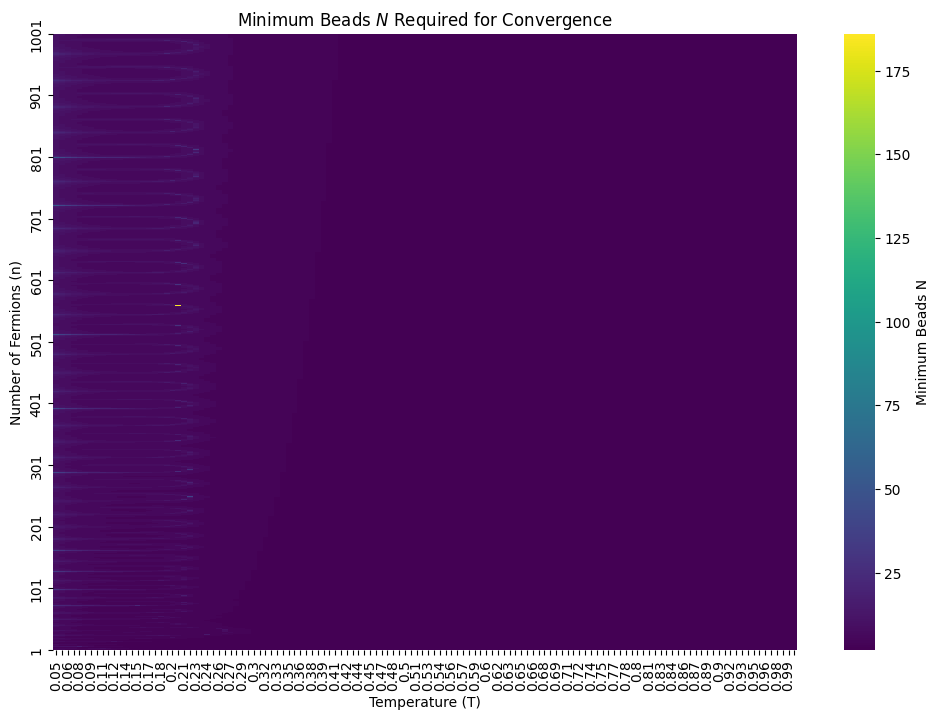

In [61]:
plt.figure(figsize=(12, 8))
# T is x-axis (columns), n is y-axis (rows)
x_labels = [str(np.round(t, 2)) if i % 2 == 0 else "" for i, t in enumerate(T_vals)]
max_val = np.max(heatmap_N[heatmap_N < 256]) if np.any(heatmap_N < 256) else 256
ax = sns.heatmap(heatmap_N, xticklabels=x_labels, yticklabels=100, cmap='viridis', vmax=max_val,
                 cbar_kws={'label': 'Minimum Beads N'})

plt.yticks(np.arange(0, max_n+1, 100), np.arange(1, max_n+2, 100))
plt.xlabel("Temperature (T)")
plt.ylabel("Number of Fermions (n)")
plt.title(r"Minimum Beads $N$ Required for Convergence")
plt.gca().invert_yaxis() # Origin at bottom-left
plt.show()
